0

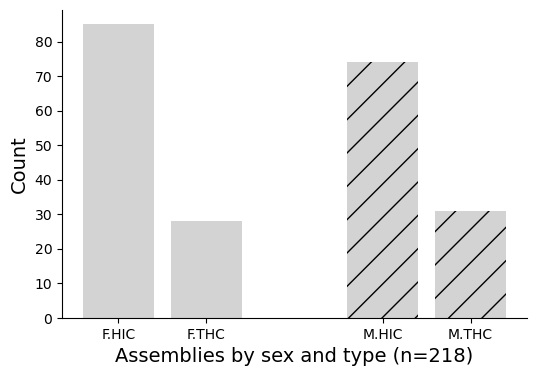

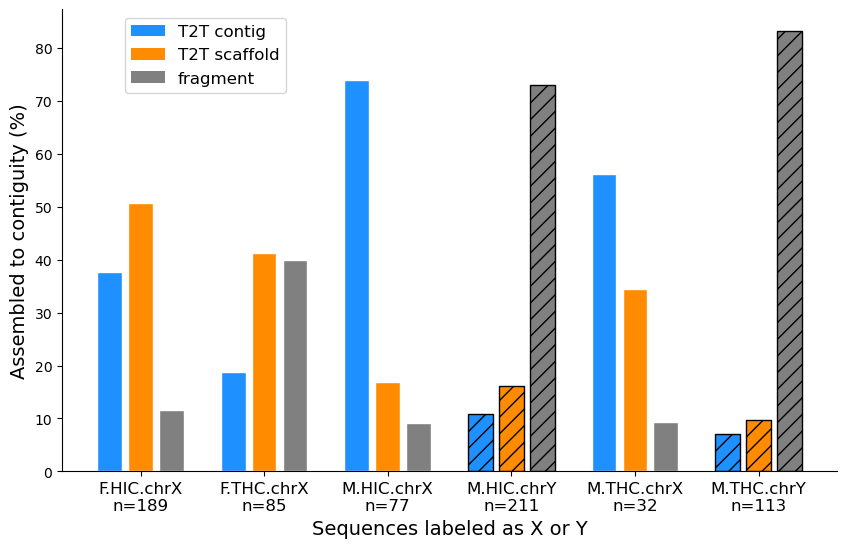

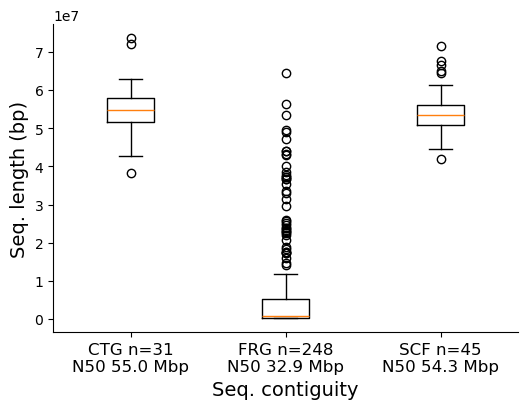

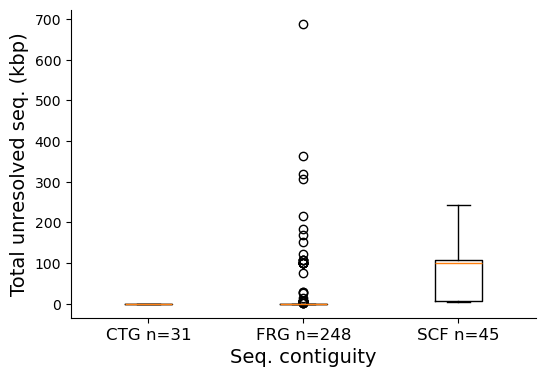

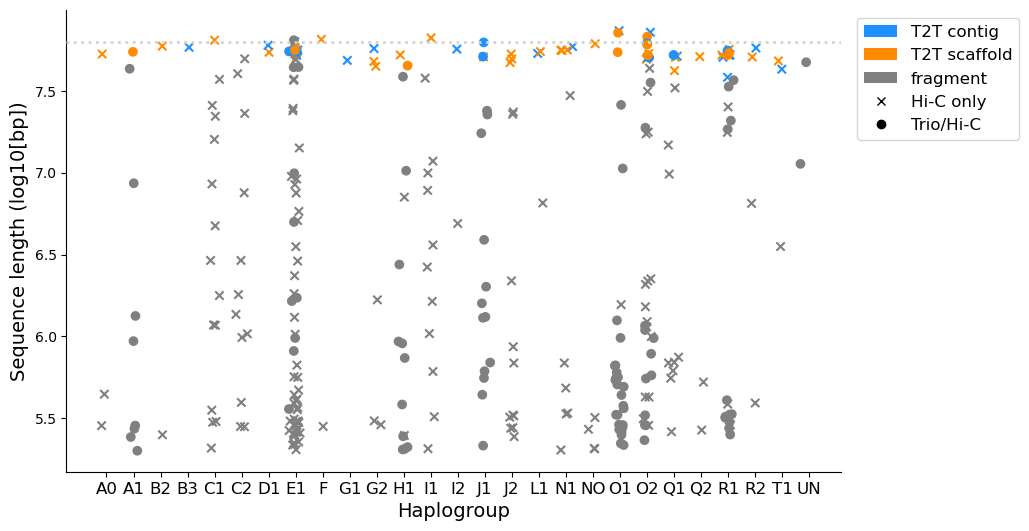

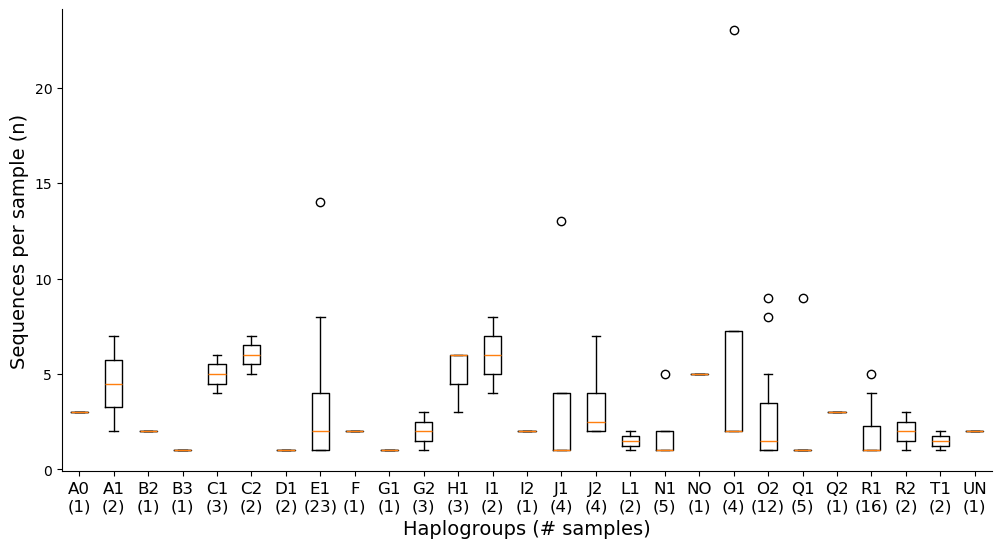

In [66]:
import pathlib as pl
import collections as col

import pandas as pd
import numpy as np

import numpy.random as rng
rng.seed()

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
PLOT_ROOT.mkdir(exist_ok=True, parents=True)


seq_rename_file = CONFIG["project_repo"].joinpath(
    "codebase/extract-sex-chromosomes/workflow/results",
    "seq_rename_composition.tsv.gz"
)

def assign_sex(table):

    select_males = table["chromosome"] == "chrY"
    male_samples = table.loc[select_males, "sample"].values
    table["sample_sex"] = "female"
    table.loc[table["sample"].isin(male_samples), "sample_sex"] = "male"
    return None

rename_table = pd.read_csv(seq_rename_file, sep="\t", header=0, comment="#")
rename_table["contiguity"] = rename_table["name"].apply(lambda n: n.split("|")[-1])
rename_table["assembly_type"] = rename_table["name"].apply(lambda n: "hic" if n.split("|")[3] == "UNK" else "thc")
rename_table["haplogroup"] = rename_table["name"].apply(lambda n: n.split("|")[2])
assign_sex(rename_table)


def add_jitter(coord):

    slack = rng.normal(0, 0.1)
    return coord+slack


def male_size_dist(table):

    male_subset = table.loc[table["chromosome"] == "chrY", :].copy()
    male_subset["log_len"] = np.log10(male_subset["seq_length"])

    haplogroups = sorted(set(male_subset["haplogroup"].values))
    hg_idx = dict((hg, pos) for pos, hg in enumerate(haplogroups, start=1))

    colormap = {
        "CTG": "dodgerblue",
        "SCF": "darkorange",
        "FRG": "gray"
    }

    points = {
        "hic": col.defaultdict(list),
        "thc": col.defaultdict(list)
    }
    
    for sample, seqs in male_subset.groupby("sample"):

        atype = seqs["assembly_type"].iloc[0]
        for seq in seqs.itertuples():
            x_val = hg_idx[seq.haplogroup]
            points[atype]["x_vals"].append(add_jitter(x_val))
            points[atype]["y_vals"].append(seq.log_len)
            color = colormap[seq.contiguity]
            points[atype]["color"].append(color)

    fig, ax = plt.subplots(figsize=(10,6))

    ax.scatter(
        points["hic"]["x_vals"],
        points["hic"]["y_vals"],
        marker="x",
        label="HiC",
        c=points["hic"]["color"]
    )

    ax.scatter(
        points["thc"]["x_vals"],
        points["thc"]["y_vals"],
        marker="o",
        label="Trio/HiC",
        c=points["thc"]["color"]
    )

    x_pos = [hg_idx[hg] for hg in haplogroups]
    x_labels = haplogroups

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=12)

    ax.set_ylabel("Sequence length (log10[bp])", fontsize=14)
    ax.set_xlabel("Haplogroup", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    custom_handles = [
        patches.Patch(facecolor='dodgerblue', edgecolor=None, label='T2T contig'),
        patches.Patch(facecolor='darkorange', edgecolor=None, label='T2T scaffold'),
        patches.Patch(facecolor='gray', edgecolor=None, label='fragment'),
        lines.Line2D([], [], ls="None", color='black', marker="x", label='Hi-C only'),
        lines.Line2D([], [], ls="None", color='black', marker="o", label='Trio/Hi-C'),
    ]

    ax.legend(handles=custom_handles, bbox_to_anchor=(1.01,1.), fontsize=12)

    ax.axhline(np.log10(62460029), 0, 1, lw=2, ls="dotted", zorder=3, color="lightgrey")

    plt.savefig(
        PLOT_ROOT.joinpath("size_dist.png"),
        dpi=300, bbox_inches="tight"
    )
    
    return


def basic_dataset_statistics(table):

    count_stats = col.Counter()
    num_males = table.loc[table["sample_sex"] == "male", "sample"].nunique()
    num_females = table.loc[table["sample_sex"] == "female", "sample"].nunique()

    bars = []
    totals = []
    labels = []
    x_pos = []
    x_label_pos = []
    bar_colors = []
    edgecolors = []
    hatch_style = []

    pos_counter = 0
    for sex in ["female", "male"]:
        select_sex = table["sample_sex"] == sex
        assert select_sex.sum() > 0
        
        for asmtype in ["hic", "thc"]:
            select_asmtype = table["assembly_type"] == asmtype
            assert select_asmtype.sum() > 0
            
            for chrom in ["chrX", "chrY"]:
                if chrom == "chrY" and sex == "female":
                    continue
                select_chrom = table["chromosome"] == chrom
                assert select_chrom.sum() > 0

                # compute_total
                running_total = (select_sex & select_asmtype & select_chrom).sum()
                
                for color, contig in zip(["dodgerblue", "darkorange", "gray"],["CTG", "SCF", "FRG"]):
                    select_contig = table["contiguity"] == contig
                    assert select_contig.sum() > 0, contig

                    selector = select_sex & select_asmtype & select_chrom & select_contig

                    bars.append(selector.sum())
                    totals.append(running_total)

                    pos_counter += 1
                    x_pos.append(pos_counter)

                    if contig == "SCF":
                        labels.append(f"{sex[0].upper()}.{asmtype.upper()}.{chrom}\nn={running_total}")
                        x_label_pos.append(pos_counter)
                    bar_colors.append(color)

                    if sex == "male" and chrom == "chrY":
                        edgecolors.append("black")
                        hatch_style.append("//")
                    else:
                        edgecolors.append("white")
                        hatch_style.append("")

                pos_counter += 1

    bars = np.array(bars, dtype=float)
    totals = np.array(totals, dtype=float)
    rel_height = (bars / totals * 100).round(1)

    fix, ax = plt.subplots(figsize=(10, 6))
   
    ax.bar(
        x_pos,
        height=rel_height,
        color=bar_colors,
        edgecolor=edgecolors,
        hatch=hatch_style
    )

    ax.set_ylabel("Assembled to contiguity (%)", fontsize=14)
    ax.set_xlabel("Sequences labeled as X or Y", fontsize=14)

    ax.set_xticks(x_label_pos)
    ax.set_xticklabels(labels, fontsize=12)

    custom_handles = [
        patches.Patch(facecolor='dodgerblue', edgecolor=None, label='T2T contig'),
        patches.Patch(facecolor='darkorange', edgecolor=None, label='T2T scaffold'),
        patches.Patch(facecolor='gray', edgecolor=None, label='fragment'),
    ]

    ax.legend(handles=custom_handles, bbox_to_anchor=(0.3,1.), fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.savefig(
        PLOT_ROOT.joinpath("assembled_contiguity_pct.png"),
        dpi=300, bbox_inches="tight"
    )

    return 0


def plot_sample_summary(table):

    sub = table.drop_duplicates("sample", inplace=False)

    counts = sub.groupby(["sample_sex", "assembly_type"]).size()
    total = counts.sum()  

    bars = []
    labels = []
    for (sex, asmtype), count in counts.items():
        label = f"{sex[0].upper()}.{asmtype.upper()}"
        labels.append(label)
        bars.append(count)

    fig, ax = plt.subplots(figsize=(6,4))

    x_pos = [1,2,4,5]
    
    ax.bar(
        x_pos,
        height=bars,
        color="lightgray",
        hatch=["", "", "/", "/"]
    )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel(f"Assemblies by sex and type (n={total})", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

    plt.savefig(
        PLOT_ROOT.joinpath("sample_summary.png"),
        dpi=300, bbox_inches="tight"
    )

    return 0


def plot_male_length_summary(table):

    select_male = table["sample_sex"] == "male"
    select_chrom = table["chromosome"] == "chrY"
    selector = select_male & select_chrom
    
    sub = table.loc[selector, :].copy()

    boxes = []
    labels = []
    n50_lengths = dict()
    num_seqs = dict()
    for contig, seqs in sub.groupby("contiguity"):
        lengths = seqs["seq_length"].sort_values(inplace=False).reset_index(drop=True, inplace=False)
        boxes.append(lengths.values)
        labels.append(contig)
        cum_length = lengths.cumsum()
        n_values = cum_length / cum_length.iloc[-1]
        select_n = n_values.index[n_values > 0.5][0]
        n50_length = lengths.loc[select_n]
        n50_lengths[contig] = round(n50_length/int(1e6),1)
        num_seqs[contig] = seqs.shape[0]

    fig, ax = plt.subplots(figsize=(6,4))

    x_pos = [1,2,3]
    
    ax.boxplot(
        boxes,
        positions=x_pos
    )

    ax.set_xticks(x_pos)
    full_labels = [
        f"{label} n={num_seqs[label]}\nN50 {n50_lengths[label]} Mbp"
        for label in labels
    ]
    ax.set_xticklabels(full_labels, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Seq. contiguity", fontsize=14)
    ax.set_ylabel("Seq. length (bp)", fontsize=14)
        
    plt.savefig(
        PLOT_ROOT.joinpath("sequence_lengths.png"),
        dpi=300, bbox_inches="tight"
    )

    return 0


def plot_male_sequence_composition(table):

    select_male = table["sample_sex"] == "male"
    select_chrom = table["chromosome"] == "chrY"
    selector = select_male & select_chrom

    sub = table.loc[selector, :].copy()

    boxes = []
    labels = []
    num_seqs = dict()
    for contig, seqs in sub.groupby("contiguity"):
        lengths = seqs["num_N"] / int(1e3)
        boxes.append(lengths.values)
        labels.append(contig)
        num_seqs[contig] = seqs.shape[0]

    fig, ax = plt.subplots(figsize=(6,4))

    x_pos = [1,2,3]
    
    ax.boxplot(
        boxes,
        positions=x_pos
    )

    ax.set_xticks(x_pos)
    full_labels = [
        f"{label} n={num_seqs[label]}"
        for label in labels
    ]
    ax.set_xticklabels(full_labels, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xlabel("Seq. contiguity", fontsize=14)
    ax.set_ylabel("Total unresolved seq. (kbp)", fontsize=14)
        
    plt.savefig(
        PLOT_ROOT.joinpath("unresolved_seq_total.png"),
        dpi=300, bbox_inches="tight"
    )

    return 0


def plot_num_assembled_sequences(table):

    select_male = table["sample_sex"] == "male"
    select_chrom = table["chromosome"] == "chrY"
    selector = select_male & select_chrom

    sub = table.loc[selector, :].copy()

    boxes = col.defaultdict(list)
    samples = col.Counter()
    
    seq_counts = sub.groupby(["sample", "haplogroup"]).size()
    for (sample, hgroup), count in seq_counts.items():
        samples[hgroup] += 1
        boxes[hgroup].append(count)

    sorted_hgroups = sorted(boxes.keys())
    boxes = [
        boxes[hgroup] for hgroup in sorted_hgroups
    ]

    fig, ax = plt.subplots(figsize=(12,6))
    
    ax.boxplot(
        boxes
    )

    full_labels = [
        f"{hgroup}\n({samples[hgroup]})"
        for hgroup in sorted_hgroups
    ]
    
    ax.set_xticklabels(full_labels, fontsize=12)

    ax.set_xlabel("Haplogroups (# samples)", fontsize=14)
    ax.set_ylabel("Sequences per sample (n)", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.savefig(
        PLOT_ROOT.joinpath("num_assembled_seqs.png"),
        dpi=300, bbox_inches="tight"
    )
    
    return 0


plot_sample_summary(rename_table)
basic_dataset_statistics(rename_table)
plot_male_length_summary(rename_table)
plot_male_sequence_composition(rename_table)
male_size_dist(rename_table)
plot_num_assembled_sequences(rename_table)



   
 
    